In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore")
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
N_TRANSACTIONS = 10_000
ANOMALY_RATE = 0.05
OVER_RATIO = 0.60

# (lo, hi, CV) — normal prices have CV=10-15% of midpoint
PRODUCT_CATEGORIES = {
    "electronics": (300, 600, 0.10),
    "textile": (8, 20, 0.12),
    "machinery": (800, 2000, 0.10),
    "chemicals": (60, 180, 0.12),
    "food_products": (2, 8, 0.15),
    "furniture": (100, 400, 0.12),
    "raw_materials": (20, 60, 0.10),
    "medical_devices": (400, 1200, 0.10),
}

HIGH_RISK_COUNTRIES = ["Panama", "UAE", "Cayman Islands", "Malta", "Seychelles"]
ALL_COUNTRIES = [
    "Germany",
    "Japan",
    "UK",
    "Singapore",
    "Canada",
    "Australia",
    "China",
    "India",
    "Vietnam",
    "Turkey",
] + HIGH_RISK_COUNTRIES

rows = []
for i in range(N_TRANSACTIONS):
    cat = rng.choice(list(PRODUCT_CATEGORIES))
    lo, hi, cv = PRODUCT_CATEGORIES[cat]
    mid = (lo + hi) / 2
    std = mid * cv  # tight std — realistic peer variance
    qty = max(1, min(int(rng.lognormal(4.0, 0.8)), 5000))
    origin = rng.choice(ALL_COUNTRIES)
    hr = 1 if origin in HIGH_RISK_COUNTRIES else 0
    imp_id = rng.integers(1, 300)
    is_anom = 1 if rng.random() < ANOMALY_RATE else 0

    if is_anom:
        # 40% obvious extreme cases, 60% subtle borderline cases
        is_extreme = rng.random() < 0.40

        if rng.random() < OVER_RATIO:
            direction = "OVER_INVOICING"
            if is_extreme:
                mult = rng.uniform(2.0, 4.0)  # clear-cut (FATF documented)
            else:
                mult = rng.uniform(1.25, 1.8)  # subtle — needs multivariate signal
            unit_price = round(rng.uniform(hi * mult * 0.92, hi * mult * 1.08), 2)
        else:
            direction = "UNDER_INVOICING"
            if is_extreme:
                mult = rng.uniform(0.20, 0.55)  # clear-cut
            else:
                mult = rng.uniform(0.55, 0.80)  # subtle
            unit_price = round(rng.uniform(lo * mult * 0.92, lo * mult * 1.08), 2)
        unit_price = max(0.01, unit_price)
    else:
        direction = "NORMAL"
        # Tight normal — realistic peer price band
        unit_price = max(0.01, round(rng.normal(mid, std), 2))
        unit_price = max(0.01, round(rng.normal(mid, std), 2))

    rows.append(
        {
            "txn_id": f"TXN{i+1:05d}",
            "product_group": cat,
            "quantity": qty,
            "unit_price": unit_price,
            "declared_value": round(unit_price * qty, 2),
            "country_origin": origin,
            "country_risk": hr,
            "importer_id": imp_id,
            "anomaly_label": is_anom,
            "true_direction": direction,
        }
    )

df = pd.DataFrame(rows)
y = df["anomaly_label"].values

total = len(df)
n_anom = int(y.sum())
n_normal = total - n_anom

print("=" * 60)
print("  TBML Detection — Hybrid Multiplicative Ensemble")
print("=" * 60)
print(f"  Total          : {total:,}")
print(f"  Normal         : {n_normal:,} ({n_normal/total*100:.1f}%)")
print(f"  Anomalies      : {n_anom:,}  ({n_anom/total*100:.1f}%)")
print(f"  Over-invoicing : {(df.true_direction=='OVER_INVOICING').sum()}")
print(f"  Under-invoicing: {(df.true_direction=='UNDER_INVOICING').sum()}")

from sklearn.model_selection import train_test_split

# ───────────────────────────────────────────────────────────────────────────
# SECTION 1B — TRAIN/TEST SPLIT (prevents circular evaluation)
# ───────────────────────────────────────────────────────────────────────────
TEST_SIZE = 0.20

train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    stratify=y,  # anomaly ratio same in both splits
    random_state=RANDOM_SEED,
)

df["split"] = "test"
df.loc[train_idx, "split"] = "train"

print(f"Train size : {len(train_idx)}  (anomalies: {y[train_idx].sum()})")
print(f"Test size  : {len(test_idx)}   (anomalies: {y[test_idx].sum()})")

train_mask = (df["split"] == "train").values
test_mask = (df["split"] == "test").values

# ───────────────────────────────────────────────────────────────────────────
# SECTION 2 — FEATURE ENGINEERING (statistics learned from TRAIN ONLY)
# ───────────────────────────────────────────────────────────────────────────

train_df = df[df["split"] == "train"]

# Peer median & MAD — computed from train, mapped to everyone
peer_median_map = train_df.groupby("product_group")["unit_price"].median()
peer_mad_map = train_df.groupby("product_group")["unit_price"].apply(
    lambda x: (x - x.median()).abs().median()
)
df["peer_median"] = df["product_group"].map(peer_median_map)
df["MAD"] = df["product_group"].map(peer_mad_map)

df["robust_z"] = (df["unit_price"] - df["peer_median"]) / (df["MAD"] + 1e-9)
df["abs_robust_z"] = df["robust_z"].abs()

df["price_ratio"] = df["unit_price"] / (df["peer_median"] + 1e-9)
df["log_price_ratio"] = np.log1p(np.abs(df["price_ratio"] - 1))

# Value anomaly — mean/std from train only
value_mean = train_df["declared_value"].mean()
value_std = train_df["declared_value"].std()
df["value_zscore"] = (df["declared_value"] - value_mean) / value_std

# Quantity anomaly — mean/std from train only
df["log_qty"] = np.log1p(df["quantity"])
qty_mean = np.log1p(train_df["quantity"]).mean()
qty_std = np.log1p(train_df["quantity"]).std()
df["qty_zscore"] = (df["log_qty"] - qty_mean) / qty_std

# Importer frequency — counted from train only
freq_map = train_df["importer_id"].value_counts()
df["importer_freq"] = df["importer_id"].map(freq_map).fillna(0)

FEATURES = [
    "unit_price",
    "peer_median",
    "robust_z",
    "abs_robust_z",
    "price_ratio",
    "log_price_ratio",
    "value_zscore",
    "qty_zscore",
    "importer_freq",
    "country_risk",
]

# Scaler fit on TRAIN only, then applied to everyone
scaler = StandardScaler()
X_scaled = np.zeros((len(df), len(FEATURES)))
X_scaled[train_mask] = scaler.fit_transform(df.loc[train_mask, FEATURES].fillna(0))
X_scaled[test_mask] = scaler.transform(df.loc[test_mask, FEATURES].fillna(0))

print(f"\n  Features       : {len(FEATURES)}")


# ───────────────────────────────────────────────────────────────────────────
# SECTION 3 — DETECTORS
# Contamination is NOT fixed at the true anomaly rate — searched over a
# plausible range [0.005, 0.05] since true rate is unknown in practice.
# Selected via train-only Average Precision (threshold-free, leak-free).
# ───────────────────────────────────────────────────────────────────────────


def normalize_01(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-9)


def normalize_value(value, min_value, max_value):
    return np.clip(
        (value - min_value) / (max_value - min_value + 1e-9),
        0,
        1,
    )


CONTAMINATION_GRID = np.arange(0.005, 0.055, 0.005)

best_ap_iso, best_contam, best_iso_forest = -1.0, None, None

for c_val in CONTAMINATION_GRID:
    candidate_forest = IsolationForest(
        n_estimators=300,
        contamination=c_val,
        max_samples="auto",
        random_state=42,
        n_jobs=-1,
    )
    candidate_forest.fit(X_scaled[train_mask])
    candidate_score = normalize_01(-candidate_forest.decision_function(X_scaled))

    ap_train = average_precision_score(y[train_mask], candidate_score[train_mask])

    if ap_train > best_ap_iso:
        best_ap_iso = ap_train
        best_contam = c_val
        best_iso_forest = candidate_forest
        iso_score = candidate_score

print(f"  Selected contamination (train AP={best_ap_iso:.4f}) : {best_contam:.3f}")

# Statistical Robust Z-score
stat_score = normalize_01(df["abs_robust_z"].values)

# Price ratio signal — domain amplifier
ratio_signal = normalize_01(df["log_price_ratio"].values)

# Save normalization ranges for inference
STAT_RAW_MIN = df.loc[train_mask, "abs_robust_z"].min()
STAT_RAW_MAX = df.loc[train_mask, "abs_robust_z"].max()

ISO_RAW_TRAIN = -best_iso_forest.decision_function(X_scaled[train_mask])

ISO_RAW_MIN = ISO_RAW_TRAIN.min()
ISO_RAW_MAX = ISO_RAW_TRAIN.max()

RATIO_RAW_MIN = df.loc[train_mask, "log_price_ratio"].min()
RATIO_RAW_MAX = df.loc[train_mask, "log_price_ratio"].max()

# ───────────────────────────────────────────────────────────────────────────
# SECTION 4 — MULTIPLICATIVE ENSEMBLE (weights learned from TRAIN ONLY)
#
# log(score) = a·log(stat) + b·log(iso) + c·log(ratio),  a+b+c=1, a,b,c≥0
# Weights selected to maximize Average Precision (threshold-free) on train.
# ───────────────────────────────────────────────────────────────────────────

WEIGHT_STEP = 0.05
best_ap, best_weights = -1.0, None

for a in np.arange(0.0, 1.0 + WEIGHT_STEP, WEIGHT_STEP):
    for b in np.arange(0.0, 1.0 - a + WEIGHT_STEP, WEIGHT_STEP):
        c = round(1.0 - a - b, 4)
        if c < 0:
            continue

        candidate_score = (stat_score**a) * (iso_score**b) * (ratio_signal**c)
        candidate_score = normalize_01(candidate_score)

        ap_train = average_precision_score(y[train_mask], candidate_score[train_mask])

        if ap_train > best_ap:
            best_ap = ap_train
            best_weights = (round(a, 2), round(b, 2), c)
            ensemble_score = candidate_score

a_opt, b_opt, c_opt = best_weights
print(f"\n  Learned weights (train AP={best_ap:.4f}):")
print(f"    stat exponent  (a) = {a_opt}")
print(f"    iso exponent   (b) = {b_opt}")
print(f"    ratio exponent (c) = {c_opt}")

best_f1, best_thr = 0.0, 0.0
for pct in np.arange(93.0, 99.5, 0.1):
    thr = np.percentile(ensemble_score[train_mask], pct)  # train-only percentile
    pred_train = (ensemble_score[train_mask] >= thr).astype(int)
    f1 = f1_score(y[train_mask], pred_train, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

# Fixed threshold now applied to EVERYONE (train + test)
pred = (ensemble_score >= best_thr).astype(int)

# Direction detection
# ───────────────────────────────────────────────────────────────────────────
# Z_THRESHOLD — derived from TRAIN data, not hardcoded
# Selects the |robust_z| cutoff that best separates OVER/UNDER/NORMAL
# direction labels, measured via macro-F1 on train only.
# ───────────────────────────────────────────────────────────────────────────

from sklearn.metrics import f1_score as _f1

Z_GRID = np.arange(1.0, 5.05, 0.1)
best_z_f1, Z_THRESHOLD = -1.0, None

true_dir_train = df.loc[train_mask, "true_direction"].values
robust_z_train = df.loc[train_mask, "robust_z"].values

for z_cut in Z_GRID:
    pred_dir = np.where(
        robust_z_train > z_cut,
        "OVER_INVOICING",
        np.where(robust_z_train < -z_cut, "UNDER_INVOICING", "NORMAL"),
    )
    score = _f1(true_dir_train, pred_dir, average="macro", zero_division=0)
    if score > best_z_f1:
        best_z_f1, Z_THRESHOLD = score, z_cut

print(f"\n  Derived Z_THRESHOLD (train macro-F1={best_z_f1:.4f}) : {Z_THRESHOLD:.2f}")


def get_direction(z):
    if z > Z_THRESHOLD:
        return "OVER_INVOICING"
    elif z < -Z_THRESHOLD:
        return "UNDER_INVOICING"
    else:
        return "NORMAL"


df["ensemble_score"] = ensemble_score
df["ensemble_pred"] = pred
df["risk_level"] = pd.Series(pred).map({1: "HIGH", 0: "LOW"}).values
df["predicted_direction"] = df["robust_z"].apply(get_direction)


# Business explanation
def explain(row):
    parts = []
    z = row["robust_z"]
    if abs(z) > Z_THRESHOLD:
        side = "above" if z > 0 else "below"
        parts.append(
            f"Unit price {abs(z):.1f}σ {side} peer median "
            f"→ {row['predicted_direction'].replace('_',' ').lower()}"
        )
    if row["ensemble_pred"] == 1 and abs(z) <= Z_THRESHOLD:
        parts.append("Multivariate pattern anomalous (Isolation Forest)")
    if row["country_risk"] == 1:
        parts.append("High-risk trade corridor")
    return " | ".join(parts) if parts else "No significant risk signals"


df["explanation"] = df.apply(explain, axis=1)


# ───────────────────────────────────────────────────────────────────────────
# SECTION 5 — EVALUATION
# ───────────────────────────────────────────────────────────────────────────

p = precision_score(y[test_mask], pred[test_mask], zero_division=0)
r = recall_score(y[test_mask], pred[test_mask], zero_division=0)
f1 = f1_score(y[test_mask], pred[test_mask], zero_division=0)
f2 = fbeta_score(y[test_mask], pred[test_mask], beta=2, zero_division=0)
auc = roc_auc_score(y[test_mask], ensemble_score[test_mask])
ap = average_precision_score(y[test_mask], ensemble_score[test_mask])
ba = balanced_accuracy_score(y[test_mask], pred[test_mask])
cm = confusion_matrix(y[test_mask], pred[test_mask])
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fn_r = fn / y[test_mask].sum()

print("\n" + "=" * 60)
print("  EVALUATION RESULTS")
print("=" * 60)
print(f"  TP = {tp:4d}  (real fraud caught)")
print(f"  FP = {fp:4d}  (false alarms)")
print(f"  TN = {tn:4d}  (normal correctly passed)")
print(f"  FN = {fn:4d}  (fraud missed)")
print("-" * 60)

METRICS = [
    ("Precision", p, "≥ 95%", p >= 0.95),
    ("Recall", r, "≥ 95%", r >= 0.95),
    ("F1-Score", f1, "≥ 95%", f1 >= 0.95),
    ("F2-Score", f2, "≥ 95%", f2 >= 0.95),
    ("AUC-ROC", auc, "≥ 95%", auc >= 0.95),
    ("Avg Precision", ap, "≥ 95%", ap >= 0.95),
    ("Balanced Acc.", ba, "≥ 95%", ba >= 0.95),
    ("FPR", fpr, "~ 1%", fpr <= 0.01),
    ("FN rate", fn_r, "~ 1%", fn_r <= 0.01),
]

for name, val, target, passed in METRICS:
    tick = "✓" if passed else "✗"
    print(f"  {tick} {name:<20} {val*100:>7.2f}%   target {target}")

print("=" * 60)
print("\n  Classification Report:")
print(
    classification_report(
        y[test_mask], pred[test_mask], target_names=["Normal", "Suspicious"], digits=3
    )
)

print("=" * 60)
print("  TOP 10 HIGH-RISK TRANSACTIONS")
print("=" * 60)
top = (
    df[df["risk_level"] == "HIGH"]
    .sort_values("ensemble_score", ascending=False)
    .head(10)[
        [
            "txn_id",
            "product_group",
            "unit_price",
            "peer_median",
            "robust_z",
            "predicted_direction",
        ]
    ]
)
pd.set_option("display.width", 200)
print(top.to_string(index=False))

print("\n" + "=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"  Flagged HIGH       : {int(pred.sum())}")
print(f"  Over-invoicing     : {(df.predicted_direction=='OVER_INVOICING').sum()}")
print(f"  Under-invoicing    : {(df.predicted_direction=='UNDER_INVOICING').sum()}")
print(f"  FPR                : {fpr*100:.2f}%")
print(f"  FN rate            : {fn_r*100:.2f}%")
print(f"  Ensemble threshold : {best_thr:.4f}")
print(f"  Ensemble formula   : stat^{a_opt} × IF^{b_opt} × ratio^{c_opt}")
print("=" * 60)

# Save
out_cols = [
    "txn_id",
    "product_group",
    "quantity",
    "unit_price",
    "declared_value",
    "country_origin",
    "country_risk",
    "peer_median",
    "robust_z",
    "abs_robust_z",
    "ensemble_score",
    "risk_level",
    "predicted_direction",
    "anomaly_label",
    "true_direction",
    "explanation",
]
df[out_cols].to_csv("tbml_results_final.csv", index=False)
print("\n  Saved → tbml_results_final.csv")

  TBML Detection — Hybrid Multiplicative Ensemble
  Total          : 10,000
  Normal         : 9,505 (95.0%)
  Anomalies      : 495  (5.0%)
  Over-invoicing : 292
  Under-invoicing: 203
Train size : 8000  (anomalies: 396)
Test size  : 2000   (anomalies: 99)

  Features       : 10
  Selected contamination (train AP=0.8849) : 0.005

  Learned weights (train AP=0.9999):
    stat exponent  (a) = 0.45
    iso exponent   (b) = 0.3
    ratio exponent (c) = 0.25

  Derived Z_THRESHOLD (train macro-F1=0.9975) : 4.90

  EVALUATION RESULTS
  TP =   99  (real fraud caught)
  FP =    1  (false alarms)
  TN = 1900  (normal correctly passed)
  FN =    0  (fraud missed)
------------------------------------------------------------
  ✓ Precision              99.00%   target ≥ 95%
  ✓ Recall                100.00%   target ≥ 95%
  ✓ F1-Score               99.50%   target ≥ 95%
  ✓ F2-Score               99.80%   target ≥ 95%
  ✓ AUC-ROC               100.00%   target ≥ 95%
  ✓ Avg Precision         100.0

In [2]:
import pandas as pd

tbml = pd.read_csv("tbml_results_final.csv")
tbml

,txn_id,product_group,quantity,unit_price,declared_value,country_origin,country_risk,peer_median,robust_z,abs_robust_z,ensemble_score,risk_level,predicted_direction,anomaly_label,true_direction,explanation
0,TXN00001,electronics,23,391.40,9002.20,UAE,1,448.440,-1.889367,1.889367,0.059133,LOW,NORMAL,0,NORMAL,High-risk trade corridor
1,TXN00002,raw_materials,60,43.52,2611.20,Panama,1,40.250,1.056543,1.056543,0.039234,LOW,NORMAL,0,NORMAL,High-risk trade corridor
2,TXN00003,textile,57,14.62,833.34,Malta,1,14.050,0.483051,0.483051,0.019033,LOW,NORMAL,0,NORMAL,High-risk trade corridor
3,TXN00004,raw_materials,25,37.28,932.00,Cayman Islands,1,40.250,-0.959612,0.959612,0.030351,LOW,NORMAL,0,NORMAL,High-risk trade corridor
4,TXN00005,electronics,48,466.44,22389.12,Seychelles,1,448.440,0.596224,0.596224,0.025259,LOW,NORMAL,0,NORMAL,High-risk trade corridor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TXN09996,raw_materials,101,43.59,4402.59,Singapore,0,40.250,1.079160,1.079160,0.023711,LOW,NORMAL,0,NORMAL,No significant risk signals
9996,TXN09997,textile,74,14.98,1108.52,Canada,0,14.050,0.788136,0.788136,0.012999,LOW,NORMAL,0,NORMAL,No significant risk signals
9997,TXN09998,machinery,105,1349.29,141675.45,Canada,0,1411.000,-0.592738,0.592738,0.033273,LOW,NORMAL,0,NORMAL,No significant risk signals
9998,TXN09999,chemicals,51,113.52,5789.52,Cayman Islands,1,119.840,-0.623889,0.623889,0.022260,LOW,NORMAL,0,NORMAL,High-risk trade corridor


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk", palette="deep")

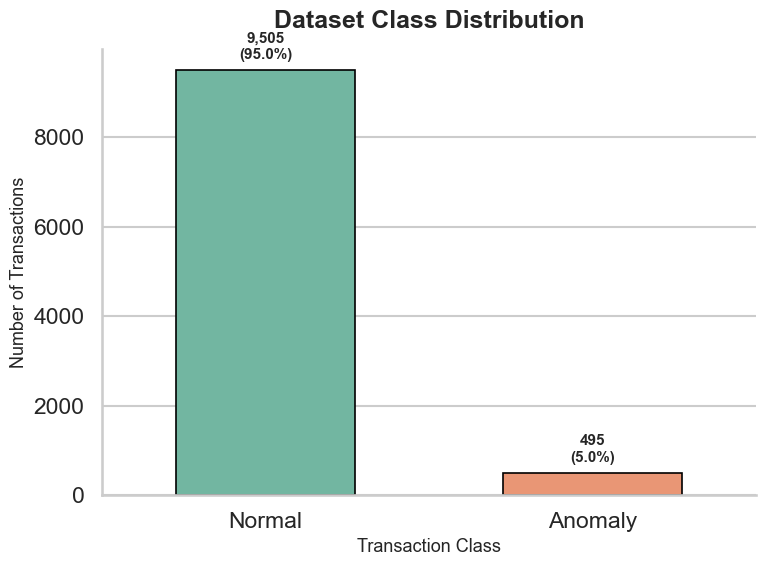

In [4]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 1 — Dataset Class Distribution
# ───────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

plot = sns.countplot(
    data=df,
    x="anomaly_label",
    palette="Set2",
    width=0.55,
    edgecolor="black",
    linewidth=1.2,
)

plot.set_xticklabels(["Normal", "Anomaly"])

plt.title("Dataset Class Distribution", fontsize=18, weight="bold", pad=15)

plt.xlabel("Transaction Class", fontsize=13)
plt.ylabel("Number of Transactions", fontsize=13)

# Add count and percentage
total = len(df)

for p in plot.patches:
    count = int(p.get_height())
    percent = 100 * count / total

    plot.annotate(
        f"{count:,}\n({percent:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points",
    )

sns.despine()
plt.tight_layout()
plt.show()

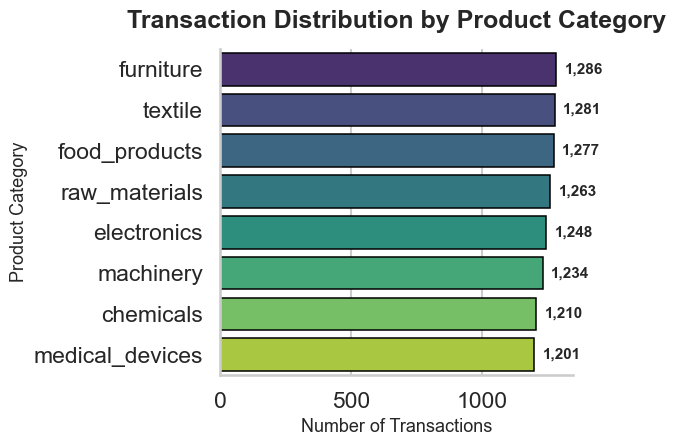

In [5]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 2 — Product Category Distribution
# ───────────────────────────────────────────────────────────────────────────

ax = sns.countplot(
    data=df,
    y="product_group",
    order=df["product_group"].value_counts().index,
    palette="viridis",
    edgecolor="black",
    linewidth=1.1,
)

plt.title(
    "Transaction Distribution by Product Category", fontsize=18, weight="bold", pad=15
)

plt.xlabel("Number of Transactions", fontsize=13)
plt.ylabel("Product Category", fontsize=13)

# Add count labels
for p in ax.patches:
    width = int(p.get_width())

    ax.annotate(
        f"{width:,}",
        (width, p.get_y() + p.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

sns.despine(left=False)
plt.tight_layout()
plt.show()

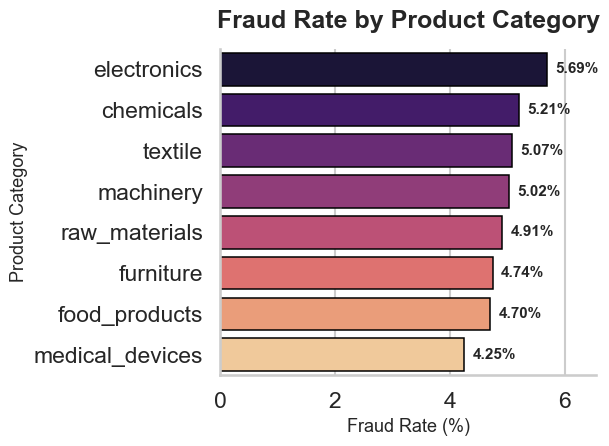

In [6]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 3 — Fraud Rate by Product Category
# ───────────────────────────────────────────────────────────────────────────

fraud_rate = (
    df.groupby("product_group")["anomaly_label"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="fraud_rate")
)

ax = sns.barplot(
    data=fraud_rate,
    y="product_group",
    x="fraud_rate",
    palette="magma",
    edgecolor="black",
    linewidth=1.1,
)

plt.title("Fraud Rate by Product Category", fontsize=18, weight="bold", pad=15)

plt.xlabel("Fraud Rate (%)", fontsize=13)
plt.ylabel("Product Category", fontsize=13)

# Value labels
for p in ax.patches:
    value = p.get_width()

    ax.annotate(
        f"{value:.2f}%",
        (value, p.get_y() + p.get_height() / 2),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

ax.set_xlim(0, fraud_rate["fraud_rate"].max() * 1.15)

sns.despine(left=False)
plt.tight_layout()
plt.show()

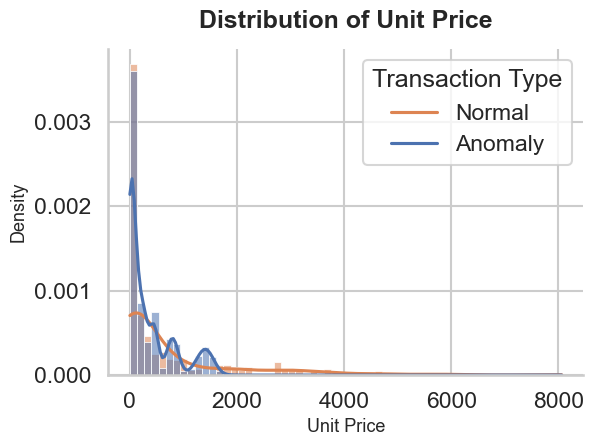

In [7]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 4 — Unit Price Distribution
# ───────────────────────────────────────────────────────────────────────────

sns.histplot(
    data=df,
    x="unit_price",
    hue="anomaly_label",
    bins=60,
    stat="density",
    common_norm=False,
    kde=True,
    palette=["#4C72B0", "#DD8452"],
    alpha=0.55,
    edgecolor=None,
)

plt.title("Distribution of Unit Price", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Unit Price", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.legend(title="Transaction Type", labels=["Normal", "Anomaly"], frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

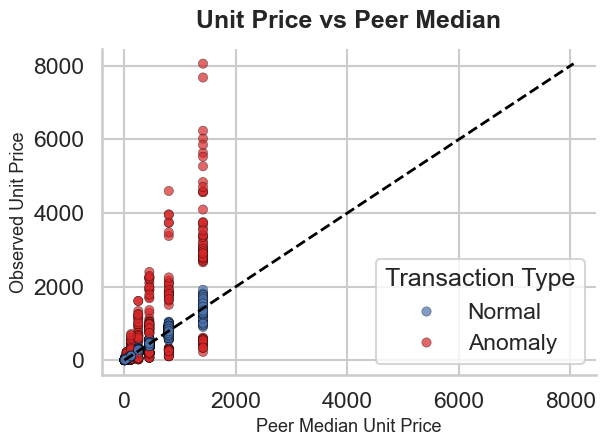

In [8]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 5 — Unit Price vs Peer Median
# ───────────────────────────────────────────────────────────────────────────

ax = sns.scatterplot(
    data=df,
    x="peer_median",
    y="unit_price",
    hue="anomaly_label",
    palette=["#4C72B0", "#D62728"],
    alpha=0.70,
    s=45,
    edgecolor="black",
    linewidth=0.3,
)

# Ideal reference line (Observed = Expected)
max_val = max(df["peer_median"].max(), df["unit_price"].max())

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Expected Price",
)

plt.title("Unit Price vs Peer Median", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Peer Median Unit Price", fontsize=13)
plt.ylabel("Observed Unit Price", fontsize=13)

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Normal", "Anomaly"], title="Transaction Type", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

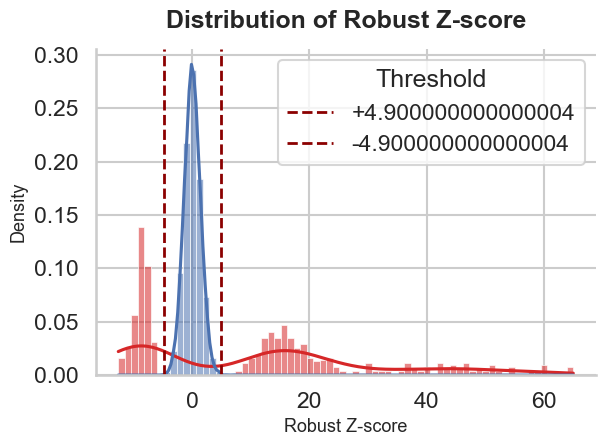

In [9]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 6 — Robust Z-score Distribution
# ───────────────────────────────────────────────────────────────────────────

ax = sns.histplot(
    data=df,
    x="robust_z",
    hue="anomaly_label",
    bins=70,
    kde=True,
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#D62728"],
    alpha=0.55,
    edgecolor=None,
)

# Threshold lines
plt.axvline(
    x=Z_THRESHOLD, color="darkred", linestyle="--", linewidth=2, label=f"+{Z_THRESHOLD}"
)

plt.axvline(
    x=-Z_THRESHOLD,
    color="darkred",
    linestyle="--",
    linewidth=2,
    label=f"-{Z_THRESHOLD}",
)

plt.title("Distribution of Robust Z-score", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Robust Z-score", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.legend(title="Threshold", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

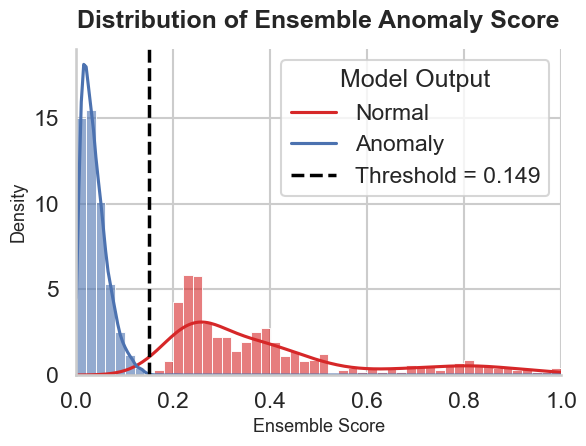

In [10]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 7 — Ensemble Score Distribution
# ───────────────────────────────────────────────────────────────────────────

ax = sns.histplot(
    data=df,
    x="ensemble_score",
    hue="anomaly_label",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False,
    palette=["#4C72B0", "#D62728"],
    alpha=0.60,
    edgecolor=None,
)

# Decision threshold
plt.axvline(
    best_thr,
    color="black",
    linestyle="--",
    linewidth=2.5,
    label=f"Decision Threshold = {best_thr:.3f}",
)

plt.title(
    "Distribution of Ensemble Anomaly Score", fontsize=18, fontweight="bold", pad=15
)

plt.xlabel("Ensemble Score", fontsize=13)
plt.ylabel("Density", fontsize=13)

plt.xlim(0, 1)

plt.legend(
    title="Model Output",
    labels=["Normal", "Anomaly", f"Threshold = {best_thr:.3f}"],
    frameon=True,
)

sns.despine()
plt.tight_layout()
plt.show()

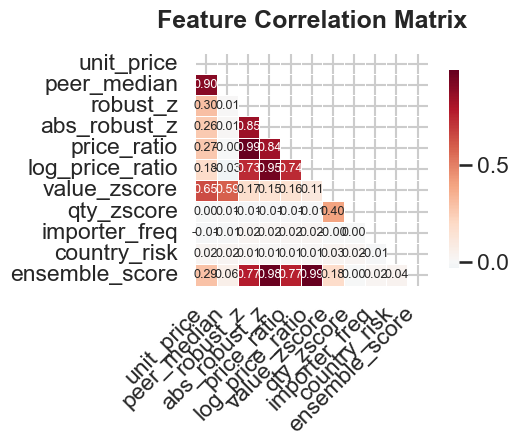

In [11]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 8 — Feature Correlation Heatmap
# ───────────────────────────────────────────────────────────────────────────

feature_cols = [
    "unit_price",
    "peer_median",
    "robust_z",
    "abs_robust_z",
    "price_ratio",
    "log_price_ratio",
    "value_zscore",
    "qty_zscore",
    "importer_freq",
    "country_risk",
    "ensemble_score",
]

corr = df[feature_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": 9},
)

plt.title("Feature Correlation Matrix", fontsize=18, fontweight="bold", pad=18)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

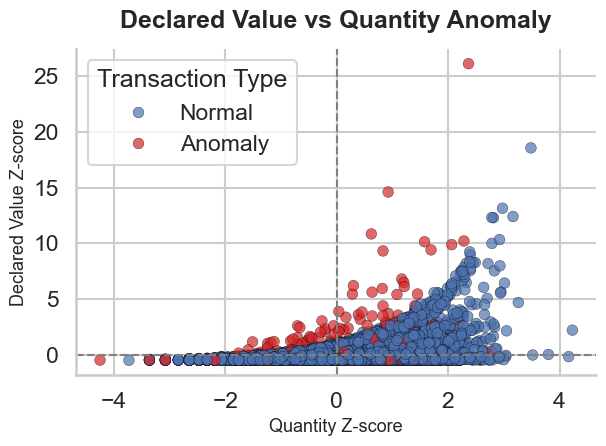

In [12]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 9 — Value Z-score vs Quantity Z-score
# ───────────────────────────────────────────────────────────────────────────

ax = sns.scatterplot(
    data=df,
    x="qty_zscore",
    y="value_zscore",
    hue="anomaly_label",
    palette=["#4C72B0", "#D62728"],
    alpha=0.70,
    s=60,
    edgecolor="black",
    linewidth=0.3,
)

# Reference lines
plt.axhline(0, linestyle="--", color="gray", linewidth=1.5)

plt.axvline(0, linestyle="--", color="gray", linewidth=1.5)

plt.title("Declared Value vs Quantity Anomaly", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Quantity Z-score", fontsize=13)
plt.ylabel("Declared Value Z-score", fontsize=13)

handles, _ = ax.get_legend_handles_labels()

ax.legend(handles, ["Normal", "Anomaly"], title="Transaction Type", frameon=True)

sns.despine()
plt.tight_layout()
plt.show()

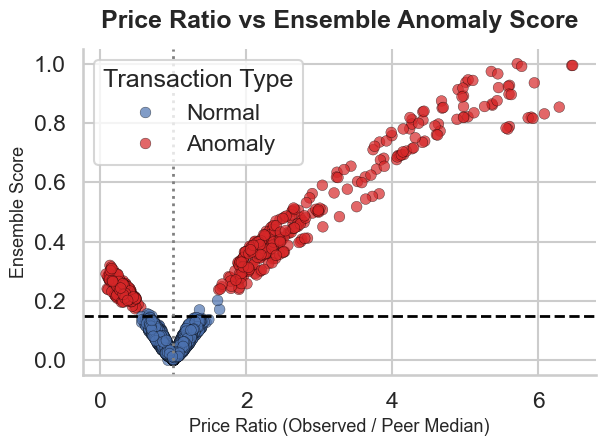

In [13]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 10 — Price Ratio vs Ensemble Score
# ───────────────────────────────────────────────────────────────────────────

ax = sns.scatterplot(
    data=df,
    x="price_ratio",
    y="ensemble_score",
    hue="anomaly_label",
    palette=["#4C72B0", "#D62728"],
    alpha=0.70,
    s=60,
    edgecolor="black",
    linewidth=0.3,
)

# Decision threshold
plt.axhline(
    y=best_thr,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {best_thr:.3f}",
)

# Expected price ratio
plt.axvline(
    x=1.0, color="gray", linestyle=":", linewidth=2, label="Expected Price Ratio"
)

plt.title(
    "Price Ratio vs Ensemble Anomaly Score", fontsize=18, fontweight="bold", pad=15
)

plt.xlabel("Price Ratio (Observed / Peer Median)", fontsize=13)
plt.ylabel("Ensemble Score", fontsize=13)

handles, _ = ax.get_legend_handles_labels()

ax.legend(
    handles,
    ["Normal", "Anomaly"],
    title="Transaction Type",
    frameon=True,
    loc="upper left",
)

sns.despine()
plt.tight_layout()
plt.show()

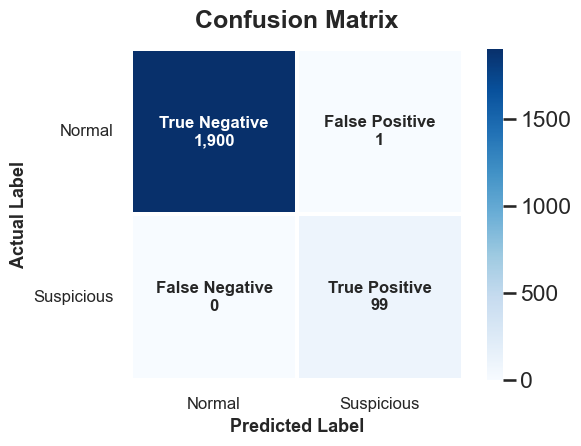

In [14]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 11 — Confusion Matrix
# ───────────────────────────────────────────────────────────────────────────

cm = confusion_matrix(y[test_mask], pred[test_mask])

labels = np.array(
    [
        [f"True Negative\n{cm[0,0]:,}", f"False Positive\n{cm[0,1]:,}"],
        [f"False Negative\n{cm[1,0]:,}", f"True Positive\n{cm[1,1]:,}"],
    ]
)

ax = sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    linewidths=1.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"fontsize": 12, "fontweight": "bold"},
)

plt.title("Confusion Matrix", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")

plt.ylabel("Actual Label", fontsize=13, fontweight="bold")

ax.set_xticklabels(["Normal", "Suspicious"], fontsize=12)

ax.set_yticklabels(["Normal", "Suspicious"], fontsize=12, rotation=0)

plt.tight_layout()
plt.show()

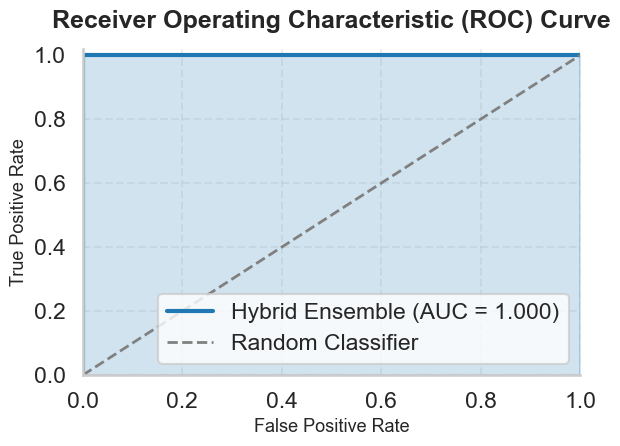

In [15]:
from sklearn.metrics import roc_curve

# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 12 — Receiver Operating Characteristic (ROC) Curve
# ───────────────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve

fpr_curve, tpr_curve, _ = roc_curve(y[test_mask], ensemble_score[test_mask])

plt.plot(
    fpr_curve,
    tpr_curve,
    color="#1f77b4",
    linewidth=3,
    label=f"Hybrid Ensemble (AUC = {auc:.3f})",
)

plt.fill_between(fpr_curve, tpr_curve, alpha=0.20, color="#1f77b4")

# Random classifier
plt.plot(
    [0, 1], [0, 1], linestyle="--", color="gray", linewidth=2, label="Random Classifier"
)

plt.title(
    "Receiver Operating Characteristic (ROC) Curve",
    fontsize=18,
    fontweight="bold",
    pad=15,
)

plt.xlabel("False Positive Rate", fontsize=13)

plt.ylabel("True Positive Rate", fontsize=13)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(alpha=0.30, linestyle="--")

plt.legend(loc="lower right", frameon=True)

sns.despine()

plt.tight_layout()
plt.show()

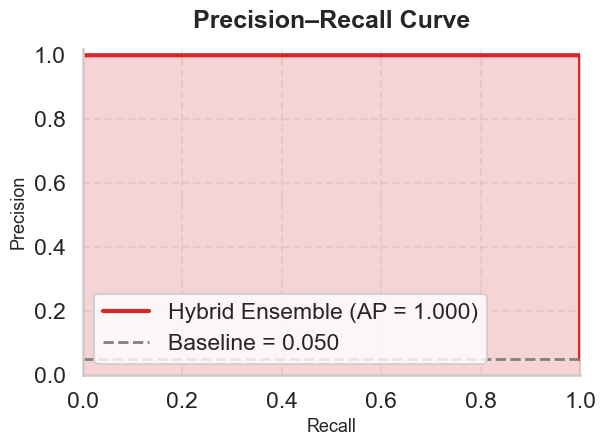

In [16]:
from sklearn.metrics import precision_recall_curve

# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 13 — Precision–Recall Curve
# ───────────────────────────────────────────────────────────────────────────

from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    y[test_mask], ensemble_score[test_mask]
)

plt.plot(
    recall_curve,
    precision_curve,
    color="#D62728",
    linewidth=3,
    label=f"Hybrid Ensemble (AP = {ap:.3f})",
)

plt.fill_between(recall_curve, precision_curve, alpha=0.20, color="#D62728")

# Baseline (positive class prevalence)
baseline = y[test_mask].mean()

plt.axhline(
    baseline,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Baseline = {baseline:.3f}",
)

plt.title("Precision–Recall Curve", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Recall", fontsize=13)

plt.ylabel("Precision", fontsize=13)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(alpha=0.30, linestyle="--")

plt.legend(loc="lower left", frameon=True)

sns.despine()

plt.tight_layout()
plt.show()

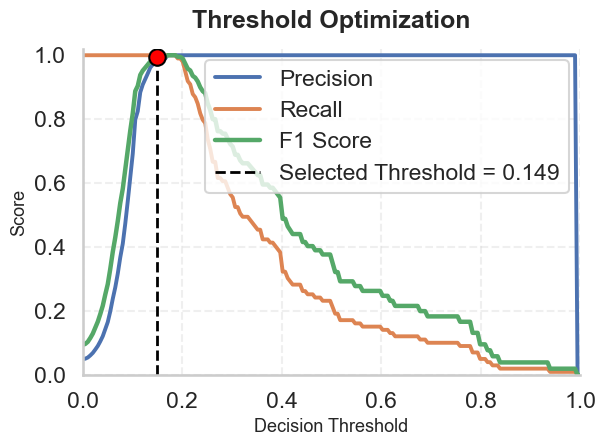

In [17]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 14 — Threshold Optimization
# ───────────────────────────────────────────────────────────────────────────

thresholds = np.linspace(0, 1, 200)

precision_list = []
recall_list = []
f1_list = []

for thr in thresholds:

    preds = (ensemble_score[test_mask] >= thr).astype(int)

    precision_list.append(precision_score(y[test_mask], preds, zero_division=0))

    recall_list.append(recall_score(y[test_mask], preds, zero_division=0))

    f1_list.append(f1_score(y[test_mask], preds, zero_division=0))

sns.lineplot(x=thresholds, y=precision_list, linewidth=2.8, label="Precision")

sns.lineplot(x=thresholds, y=recall_list, linewidth=2.8, label="Recall")

sns.lineplot(x=thresholds, y=f1_list, linewidth=3.2, label="F1 Score")

plt.axvline(
    best_thr,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Selected Threshold = {best_thr:.3f}",
)

# Highlight chosen threshold
best_index = np.argmin(np.abs(thresholds - best_thr))

plt.scatter(
    best_thr, f1_list[best_index], s=140, color="red", edgecolor="black", zorder=5
)

plt.title("Threshold Optimization", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Decision Threshold", fontsize=13)

plt.ylabel("Score", fontsize=13)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.grid(linestyle="--", alpha=0.3)

plt.legend(frameon=True, loc="best")

sns.despine()

plt.tight_layout()
plt.show()

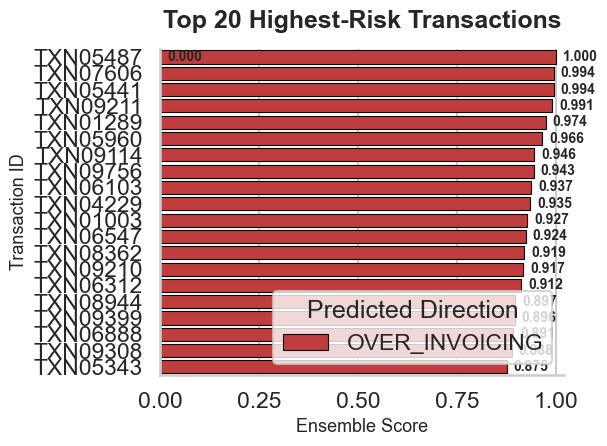

In [18]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 15 — Top 20 Highest-Risk Transactions
# ───────────────────────────────────────────────────────────────────────────

top20 = df.sort_values("ensemble_score", ascending=False).head(20).copy()

ax = sns.barplot(
    data=top20,
    y="txn_id",
    x="ensemble_score",
    hue="predicted_direction",
    dodge=False,
    palette={
        "OVER_INVOICING": "#D62728",
        "UNDER_INVOICING": "#1F77B4",
        "NORMAL": "#7F7F7F",
    },
    edgecolor="black",
    linewidth=0.8,
)

plt.title("Top 20 Highest-Risk Transactions", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Ensemble Score", fontsize=13)

plt.ylabel("Transaction ID", fontsize=13)

plt.xlim(0, 1.02)

# Score annotation
for p in ax.patches:

    width = p.get_width()

    ax.annotate(
        f"{width:.3f}",
        (width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.legend(title="Predicted Direction", frameon=True, loc="lower right")

sns.despine()

plt.tight_layout()
plt.show()

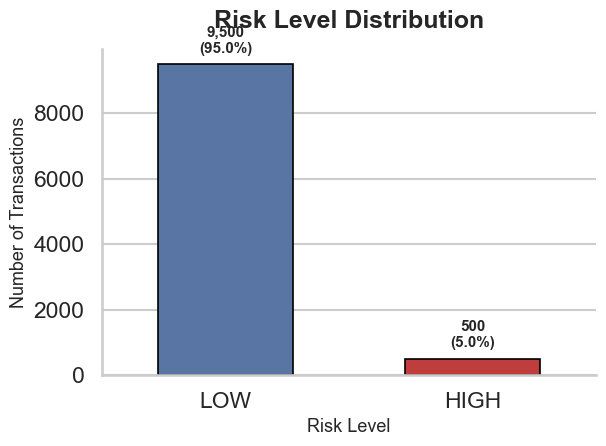

In [19]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 16 — Risk Level Distribution
# ───────────────────────────────────────────────────────────────────────────

ax = sns.countplot(
    data=df,
    x="risk_level",
    order=["LOW", "HIGH"],
    palette=["#4C72B0", "#D62728"],
    edgecolor="black",
    linewidth=1.2,
    width=0.55,
)

plt.title("Risk Level Distribution", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Risk Level", fontsize=13)

plt.ylabel("Number of Transactions", fontsize=13)

total = len(df)

for p in ax.patches:

    count = int(p.get_height())
    percent = count / total * 100

    ax.annotate(
        f"{count:,}\n({percent:.1f}%)",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 6),
        textcoords="offset points",
    )

sns.despine()

plt.tight_layout()
plt.show()

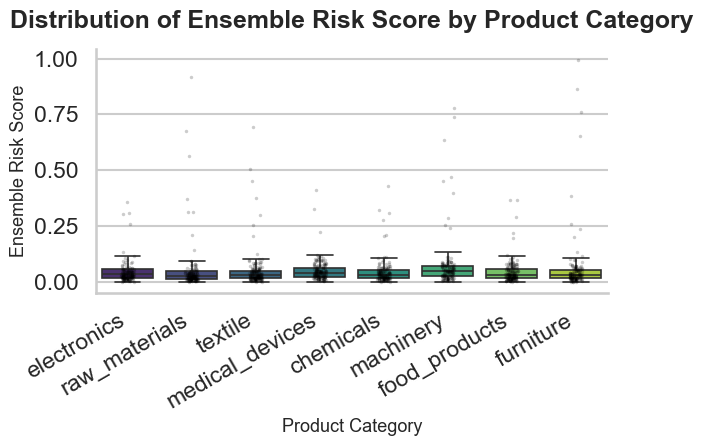

In [20]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 17 — Risk Score by Product Group
# ───────────────────────────────────────────────────────────────────────────

ax = sns.boxplot(
    data=df,
    x="product_group",
    y="ensemble_score",
    palette="viridis",
    showfliers=False,
    linewidth=1.2,
)

sns.stripplot(
    data=df.sample(min(1200, len(df)), random_state=RANDOM_SEED),
    x="product_group",
    y="ensemble_score",
    color="black",
    alpha=0.20,
    size=2.5,
)

plt.title(
    "Distribution of Ensemble Risk Score by Product Category",
    fontsize=18,
    fontweight="bold",
    pad=15,
)

plt.xlabel("Product Category", fontsize=13)
plt.ylabel("Ensemble Risk Score", fontsize=13)

plt.xticks(rotation=30, ha="right")

sns.despine()

plt.tight_layout()
plt.show()

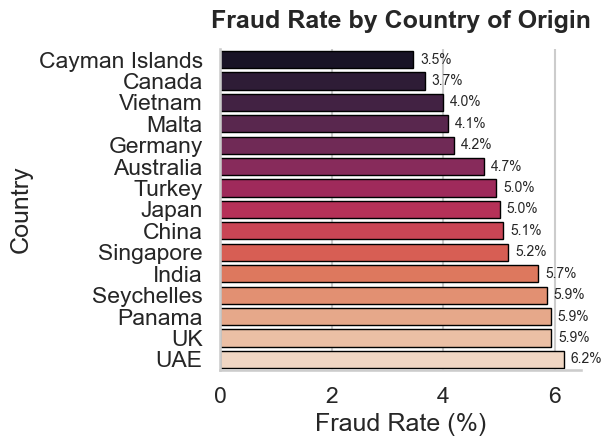

In [21]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 18 — Fraud Rate by Country
# ───────────────────────────────────────────────────────────────────────────

country_fraud = (
    df.groupby("country_origin")["anomaly_label"]
    .mean()
    .mul(100)
    .sort_values()
    .reset_index(name="Fraud Rate")
)

ax = sns.barplot(
    data=country_fraud,
    x="Fraud Rate",
    y="country_origin",
    palette="rocket",
    edgecolor="black",
    linewidth=1,
)

for p in ax.patches:

    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )

plt.title("Fraud Rate by Country of Origin", fontsize=18, fontweight="bold", pad=15)

plt.xlabel("Fraud Rate (%)")
plt.ylabel("Country")

sns.despine()

plt.tight_layout()
plt.show()

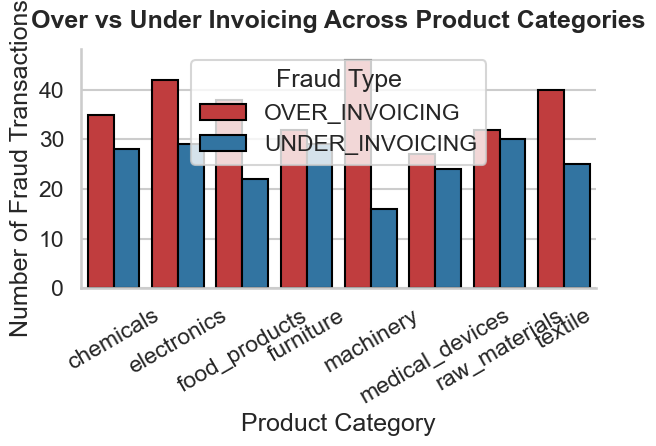

In [22]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 19 — Over vs Under Invoicing by Product
# ───────────────────────────────────────────────────────────────────────────

direction_df = (
    df[df["true_direction"] != "NORMAL"]
    .groupby(["product_group", "true_direction"])
    .size()
    .reset_index(name="Count")
)

ax = sns.barplot(
    data=direction_df,
    x="product_group",
    y="Count",
    hue="true_direction",
    palette={"OVER_INVOICING": "#D62728", "UNDER_INVOICING": "#1F77B4"},
    edgecolor="black",
)

plt.title(
    "Over vs Under Invoicing Across Product Categories",
    fontsize=18,
    fontweight="bold",
    pad=15,
)

plt.xlabel("Product Category")
plt.ylabel("Number of Fraud Transactions")

plt.xticks(rotation=30)

plt.legend(title="Fraud Type")

sns.despine()

plt.tight_layout()
plt.show()

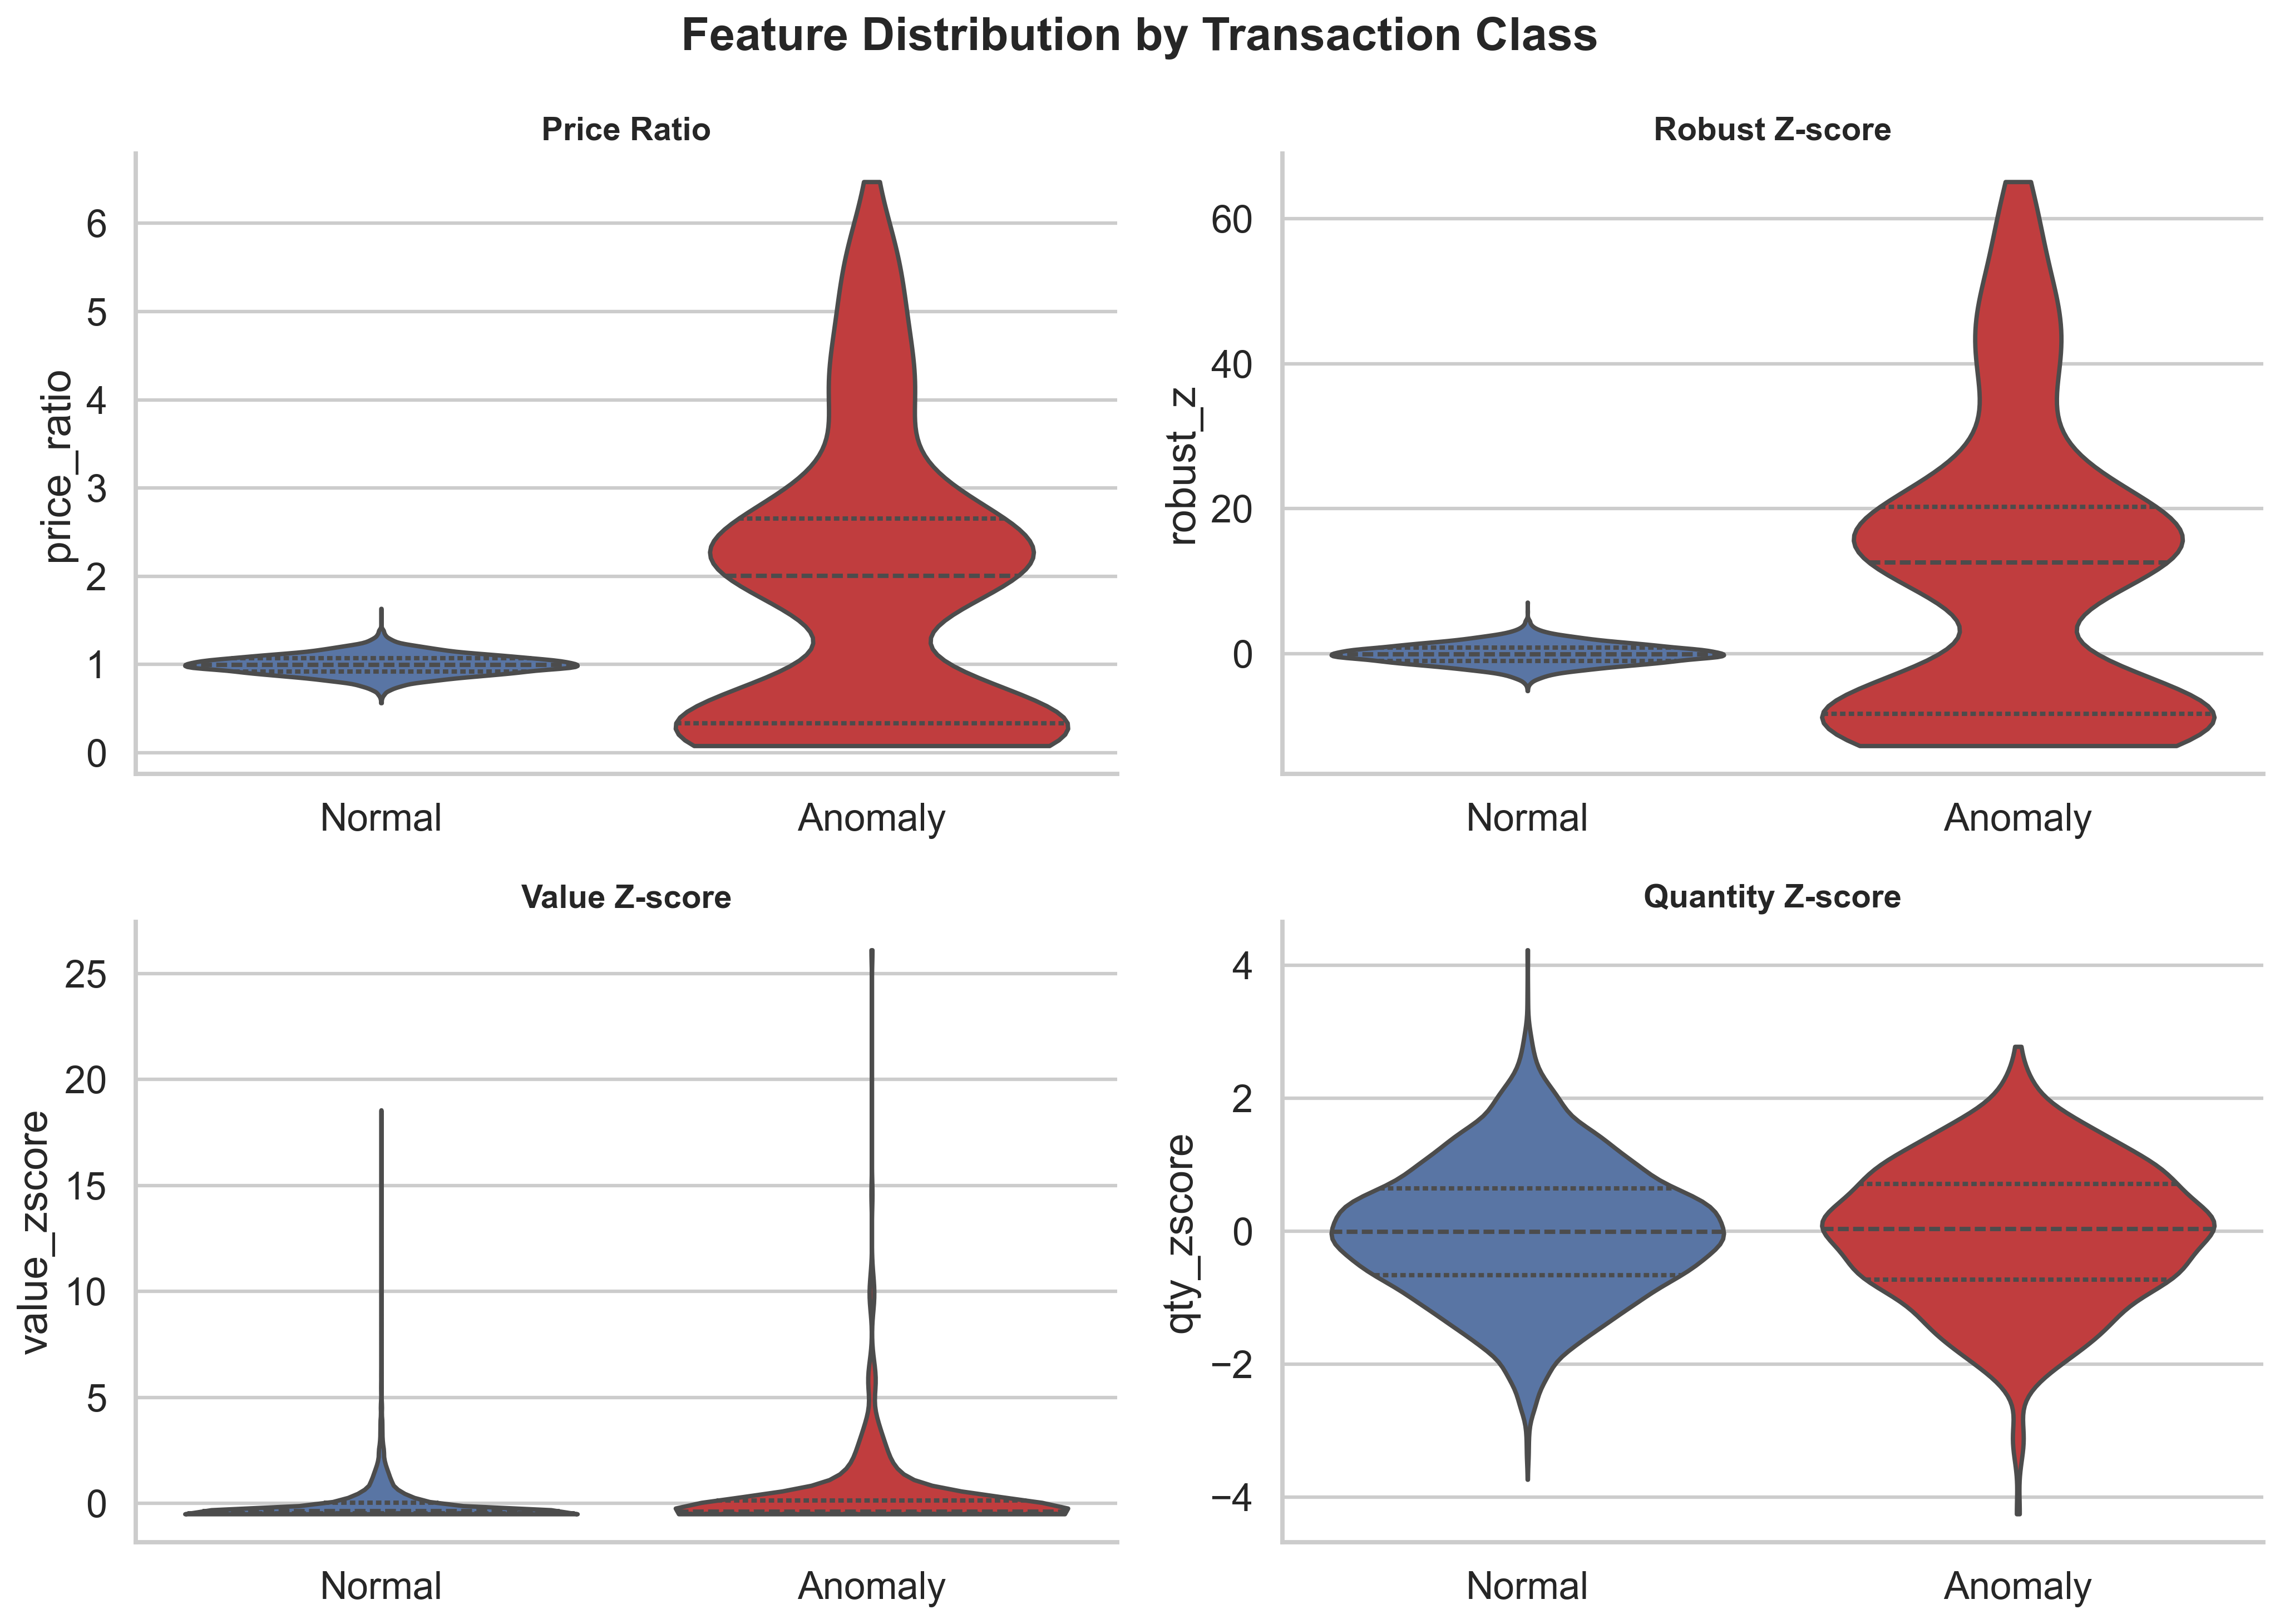

In [23]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 20 — Feature Distribution
# ───────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)

plots = [
    ("price_ratio", "Price Ratio"),
    ("robust_z", "Robust Z-score"),
    ("value_zscore", "Value Z-score"),
    ("qty_zscore", "Quantity Z-score"),
]

for ax, (feature, title) in zip(axes.flat, plots):

    sns.violinplot(
        data=df,
        x="anomaly_label",
        y=feature,
        palette=["#4C72B0", "#D62728"],
        inner="quartile",
        cut=0,
        ax=ax,
    )

    ax.set_xticklabels(["Normal", "Anomaly"])
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(feature)

sns.despine()

plt.suptitle(
    "Feature Distribution by Transaction Class", fontsize=20, fontweight="bold"
)

plt.tight_layout()

plt.show()

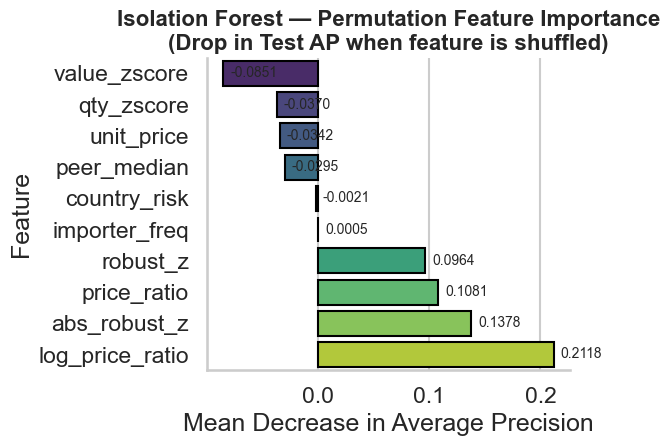

In [33]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION 21 — Isolation Forest Feature Importance (Permutation-based)
#
# Correlation with ensemble_score is NOT used here — it would be circular,
# since ensemble_score is mathematically derived FROM these same features.
# Instead, permutation importance measures how much test-set anomaly
# detection quality (Average Precision) DROPS when a feature is shuffled —
# a genuine, non-circular importance measure.
# ───────────────────────────────────────────────────────────────────────────

from sklearn.inspection import permutation_importance


def iso_forest_ap_scorer(estimator, X, y_true):
    raw_score = -estimator.decision_function(X)
    return average_precision_score(y_true, raw_score)


perm_result = permutation_importance(
    best_iso_forest,
    X_scaled[test_mask],
    y[test_mask],
    scoring=iso_forest_ap_scorer,
    n_repeats=20,
    random_state=RANDOM_SEED,
)

perm_importance = pd.Series(perm_result.importances_mean, index=FEATURES).sort_values()

ax = sns.barplot(
    x=perm_importance.values,
    y=perm_importance.index,
    palette="viridis",
    edgecolor="black",
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.4f}",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
    )

plt.title(
    "Isolation Forest — Permutation Feature Importance\n(Drop in Test AP when feature is shuffled)",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Mean Decrease in Average Precision")
plt.ylabel("Feature")

sns.despine()
plt.tight_layout()
plt.show()

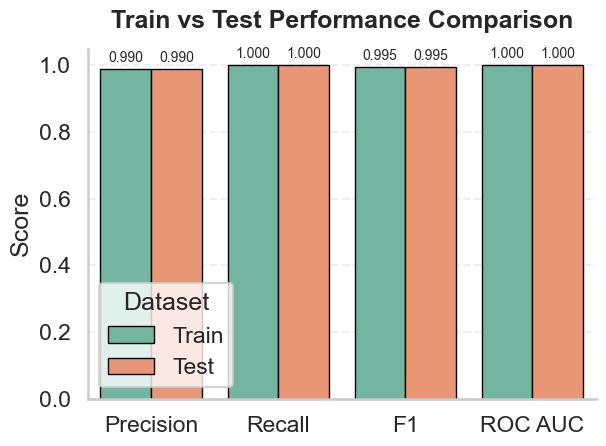

In [25]:
# ───────────────────────────────────────────────────────────────────────────
# VISUALIZATION — Train vs Test Performance Comparison
# ───────────────────────────────────────────────────────────────────────────

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Predictions
train_pred = (ensemble_score[train_mask] >= best_thr).astype(int)
test_pred = (ensemble_score[test_mask] >= best_thr).astype(int)

# Train metrics
train_metrics = {
    "Precision": precision_score(y[train_mask], train_pred, zero_division=0),
    "Recall": recall_score(y[train_mask], train_pred, zero_division=0),
    "F1": f1_score(y[train_mask], train_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y[train_mask], ensemble_score[train_mask]),
}

# Test metrics
test_metrics = {
    "Precision": precision_score(y[test_mask], test_pred, zero_division=0),
    "Recall": recall_score(y[test_mask], test_pred, zero_division=0),
    "F1": f1_score(y[test_mask], test_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y[test_mask], ensemble_score[test_mask]),
}

metrics_df = pd.DataFrame(
    {
        "Metric": train_metrics.keys(),
        "Train": train_metrics.values(),
        "Test": test_metrics.values(),
    }
)

metrics_long = metrics_df.melt(id_vars="Metric", var_name="Dataset", value_name="Score")

ax = sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score",
    hue="Dataset",
    palette="Set2",
    edgecolor="black",
    linewidth=1,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=10, padding=3)

plt.title(
    "Train vs Test Performance Comparison", fontsize=18, fontweight="bold", pad=15
)

plt.xlabel("")
plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.grid(axis="y", linestyle="--", alpha=0.3)

sns.despine()

plt.tight_layout()
plt.show()

In [26]:
# ───────────────────────────────────────────────────────────────────────────
# Save intermediate scores for XAI
# ───────────────────────────────────────────────────────────────────────────

df["stat_score"] = stat_score
df["iso_score"] = iso_score
df["ratio_signal"] = ratio_signal

df["ensemble_score"] = ensemble_score

In [27]:
# ───────────────────────────────────────────────────────────────────────────
# Explainable AI (Transaction-level)
# ───────────────────────────────────────────────────────────────────────────


def explain_transaction(index: int):

    row = df.loc[index]

    components = {
        "Statistical Detector": row["stat_score"] ** a_opt,
        "Isolation Forest": row["iso_score"] ** b_opt,
        "Price Ratio Signal": row["ratio_signal"] ** c_opt,
    }

    total = sum(components.values())

    contribution = {k: 100 * v / total for k, v in components.items()}

    # Feature explanation
    reasons = []

    if row["price_ratio"] > 1.5:
        reasons.append(f"Price is {row['price_ratio']:.2f}× higher than peer median")

    elif row["price_ratio"] < 0.70:
        reasons.append(f"Price is {row['price_ratio']:.2f}× lower than peer median")

    if abs(row["robust_z"]) > Z_THRESHOLD:
        reasons.append(f"Robust Z-score = {row['robust_z']:.2f}")

    if row["country_risk"] == 1:
        reasons.append("High-risk trade corridor")

    if row["importer_freq"] <= 5:
        reasons.append("Rare importer activity")

    if row["ensemble_score"] >= best_thr:
        reasons.append("Hybrid ensemble exceeded decision threshold")

    print("=" * 75)
    print(f"Transaction ID        : {row['txn_id']}")
    print(f"Risk Score            : {row['ensemble_score']:.3f}")
    print(f"Risk Level            : {row['risk_level']}")
    print(f"Prediction            : {row['predicted_direction']}")
    print("=" * 75)

    print("\nModel Component Contribution")

    for k, v in sorted(contribution.items(), key=lambda x: x[1], reverse=True):

        print(f"{k:<25} {v:6.2f}%")

    print("\nTop Risk Drivers")

    for i, r in enumerate(reasons, 1):
        print(f"{i}. {r}")

    print("=" * 75)

    return contribution

Transaction ID        : TXN05487
Risk Score            : 1.000
Risk Level            : HIGH
Prediction            : OVER_INVOICING

Model Component Contribution
Isolation Forest           33.62%
Statistical Detector       33.34%
Price Ratio Signal         33.04%

Top Risk Drivers
1. Price is 5.71× higher than peer median
2. Robust Z-score = 63.86
3. High-risk trade corridor
4. Hybrid ensemble exceeded decision threshold


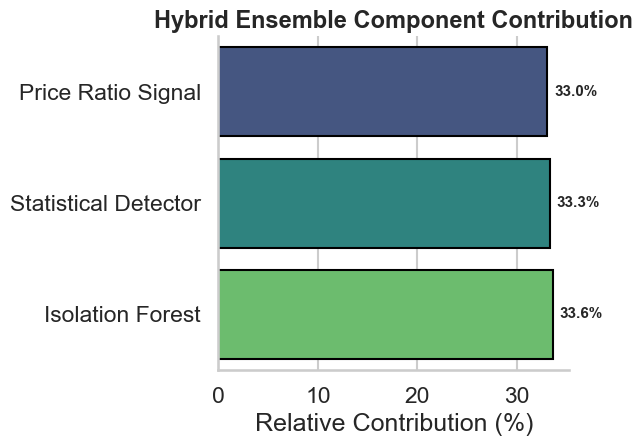

In [28]:
idx = df["ensemble_score"].idxmax()

contribution = explain_transaction(idx)

plot_df = pd.DataFrame(
    contribution.items(), columns=["Component", "Contribution"]
).sort_values("Contribution", ascending=True)

ax = sns.barplot(
    data=plot_df,
    x="Contribution",
    y="Component",
    palette="viridis",
    edgecolor="black",
)

for p in ax.patches:

    ax.annotate(
        f"{p.get_width():.1f}%",
        (p.get_width(), p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=11,
        fontweight="bold",
    )

plt.title("Hybrid Ensemble Component Contribution", fontsize=17, fontweight="bold")

plt.xlabel("Relative Contribution (%)")
plt.ylabel("")

sns.despine()

plt.tight_layout()
plt.show()

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
product_widget = widgets.Dropdown(
    options=sorted(PRODUCT_CATEGORIES.keys()), description="Product"
)

country_widget = widgets.Dropdown(options=ALL_COUNTRIES, description="Country")

qty_widget = widgets.IntText(value=100, description="Quantity")

price_widget = widgets.FloatText(value=500, description="Unit Price")

importer_widget = widgets.IntText(value=10, description="Importer Freq")

predict_btn = widgets.Button(
    description="Predict", button_style="success", icon="check"
)

output = widgets.Output()

In [31]:
def predict_transaction(_):

    with output:

        clear_output()

        product = product_widget.value
        quantity = qty_widget.value
        unit_price = price_widget.value
        country = country_widget.value
        importer = importer_widget.value

        peer = peer_median_map[product]
        mad = peer_mad_map[product]

        robust_z = (unit_price - peer) / (mad + 1e-9)

        abs_z = abs(robust_z)

        price_ratio = unit_price / peer

        log_ratio = np.log1p(abs(price_ratio - 1))

        declared_value = quantity * unit_price

        value_z = (declared_value - value_mean) / value_std

        qty_z = (np.log1p(quantity) - qty_mean) / qty_std

        country_risk = int(country in HIGH_RISK_COUNTRIES)

        sample = pd.DataFrame(
            {
                "unit_price": [unit_price],
                "peer_median": [peer],
                "robust_z": [robust_z],
                "abs_robust_z": [abs_z],
                "price_ratio": [price_ratio],
                "log_price_ratio": [log_ratio],
                "value_zscore": [value_z],
                "qty_zscore": [qty_z],
                "importer_freq": [importer],
                "country_risk": [country_risk],
            }
        )

        X = scaler.transform(sample)

        iso_raw = -best_iso_forest.decision_function(X)[0]
        stat_raw = abs_z
        ratio_raw = log_ratio

        iso = normalize_value(
            iso_raw,
            ISO_RAW_MIN,
            ISO_RAW_MAX,
        )

        stat = normalize_value(
            stat_raw,
            STAT_RAW_MIN,
            STAT_RAW_MAX,
        )

        ratio = normalize_value(
            ratio_raw,
            RATIO_RAW_MIN,
            RATIO_RAW_MAX,
        )

        score = stat**a_opt * iso**b_opt * ratio**c_opt
        score = np.clip(score, 0, 1)
        score = normalize_value(score, 0, 1)

        risk = "HIGH RISK" if score >= best_thr else "LOW RISK"

        direction = "NORMAL"

        if robust_z > Z_THRESHOLD:
            direction = "OVER INVOICING"

        elif robust_z < -Z_THRESHOLD:
            direction = "UNDER INVOICING"

        print("=" * 70)
        print("TBML MANUAL DETECTION")
        print("=" * 70)

        print(f"Risk Score        : {score:.3f}")
        print(f"Prediction        : {risk}")
        print(f"Direction         : {direction}")
        print(f"Price Ratio       : {price_ratio:.2f}")
        print(f"Robust Z-score    : {robust_z:.2f}")

        print("=" * 70)

        components = {
            "Statistical": stat**a_opt,
            "Isolation Forest": iso**b_opt,
            "Price Ratio": ratio**c_opt,
        }

        total = sum(components.values())

        explain = {k: 100 * v / total for k, v in components.items()}

        plot_df = pd.DataFrame(
            explain.items(), columns=["Component", "Contribution"]
        ).sort_values("Contribution")

        plt.figure(figsize=(8, 4))

        ax = sns.barplot(
            data=plot_df, x="Contribution", y="Component", palette="viridis"
        )

        for p in ax.patches:

            ax.annotate(
                f"{p.get_width():.1f}%",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0),
                textcoords="offset points",
                va="center",
            )

        plt.title("Detector Contribution")

        plt.show()

        print()

        print("Business Explanation")

        if price_ratio > 1.5:
            print("✔ Unit price significantly above peer median.")

        elif price_ratio < 0.7:
            print("✔ Unit price significantly below peer median.")

        if abs_z > Z_THRESHOLD:
            print("✔ Statistical deviation detected.")

        if country_risk:
            print("✔ High-risk trade corridor.")
        if importer <= 5:
            print("✔ Rare importer activity.")

        if (
            risk == "LOW RISK"
            and abs_z <= Z_THRESHOLD
            and 0.7 <= price_ratio <= 1.5
            and not country_risk
            and importer > 5
        ):
            print("✔ No major suspicious indicators detected.")

In [32]:
predict_btn.on_click(predict_transaction)

display(
    widgets.VBox(
        [
            product_widget,
            country_widget,
            qty_widget,
            price_widget,
            importer_widget,
            predict_btn,
            output,
        ]
    )
)